# CSV 테이블 간 관계 분석

자동차 도장 품질 검사 데이터셋의 테이블 관계, 마스터 분포, 이미지-정형 데이터 연결 가능성을 분석한다.

In [1]:
# ── 환경 설정 ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import platform, os, warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 자동 감지 ──
def setup_korean_font():
    system = platform.system()
    if system == 'Windows':
        candidates = ['Malgun Gothic', 'NanumGothic', 'Gulim']
    elif system == 'Darwin':
        candidates = ['AppleGothic', 'Apple SD Gothic Neo']
    else:
        candidates = ['NanumGothic', 'NanumBarunGothic', 'UnDotum', 'DejaVu Sans']
    from matplotlib.font_manager import fontManager
    available = {f.name for f in fontManager.ttflist}
    for font in candidates:
        if font in available:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            print(f'한글 폰트: {font}')
            return font
    print('한글 폰트를 찾지 못했습니다.')
    return None

setup_korean_font()
plt.rcParams['figure.dpi'] = 100

DATA = Path('track_a_data')
IMG_DIR = Path('track_a_images')
print('환경 설정 완료')

한글 폰트: Malgun Gothic
환경 설정 완료


In [2]:
# ── 데이터 로드 ──
import yaml
ins = pd.read_csv(DATA / 'inspection_master.csv')
defect = pd.read_csv(DATA / 'defect_detail.csv')
daily = pd.read_csv(DATA / 'daily_summary.csv')
m_color = pd.read_csv(DATA / 'master_color.csv', encoding='utf-8-sig')
m_defect = pd.read_csv(DATA / 'master_defect_type.csv', encoding='utf-8-sig')
m_plant = pd.read_csv(DATA / 'master_plant_line.csv', encoding='utf-8-sig')
m_model = pd.read_csv(DATA / 'master_model.csv', encoding='utf-8-sig')
m_zone = pd.read_csv(DATA / 'master_zone.csv', encoding='utf-8-sig')
m_camera = pd.read_csv(DATA / 'master_camera.csv', encoding='utf-8-sig')

# 이미지 측 메타데이터 로드 (data.yaml, classes.txt, metadata.json)
import json as _jsonlib
with open(IMG_DIR / 'data.yaml', 'r', encoding='utf-8') as f:
    data_yaml = yaml.safe_load(f)
with open(IMG_DIR / 'metadata.json', 'r', encoding='utf-8') as f:
    metadata = _jsonlib.load(f)
classes_txt = (IMG_DIR / 'classes.txt').read_text(encoding='utf-8').strip().split('\n')

print(f'inspection_master: {ins.shape}')
print(f'defect_detail:     {defect.shape}')
print(f'daily_summary:     {daily.shape}')
print(f'마스터 테이블: color({len(m_color)}), defect_type({len(m_defect)}), '
      f'plant_line({len(m_plant)}), model({len(m_model)}), zone({len(m_zone)}), camera({len(m_camera)})')
print(f"\n이미지 메타: data.yaml nc={data_yaml['nc']}, metadata total={metadata['total_images']}")
print(f'classes.txt: {classes_txt}')


inspection_master: (3000000, 16)
defect_detail:     (170904, 17)
daily_summary:     (318812, 14)
마스터 테이블: color(15), defect_type(10), plant_line(13), model(12), zone(12), camera(6)

이미지 메타: data.yaml nc=8, metadata total=1000
classes.txt: ['scratch', 'dent', 'paint_bubble', 'paint_drip', 'dust', 'orange_peel', 'crack', 'gap_fault']


---
## 1. 테이블 관계 검증

### 1-1. inspection_master ↔ defect_detail 매칭 분포

=== inspection_master 1건당 defect_detail 매칭 건수 분포 ===
  결함 0건:  2,877,908건 (95.93%)
  결함 1건:     85,483건 (2.85%)
  결함 2건:     24,406건 (0.81%)
  결함 3건:     12,203건 (0.41%)

=== FAIL 건의 결함 수 분포 ===


  결함 1건:     85,483건 (70.02%)
  결함 2건:     24,406건 (19.99%)


  결함 3건:     12,203건 (9.99%)


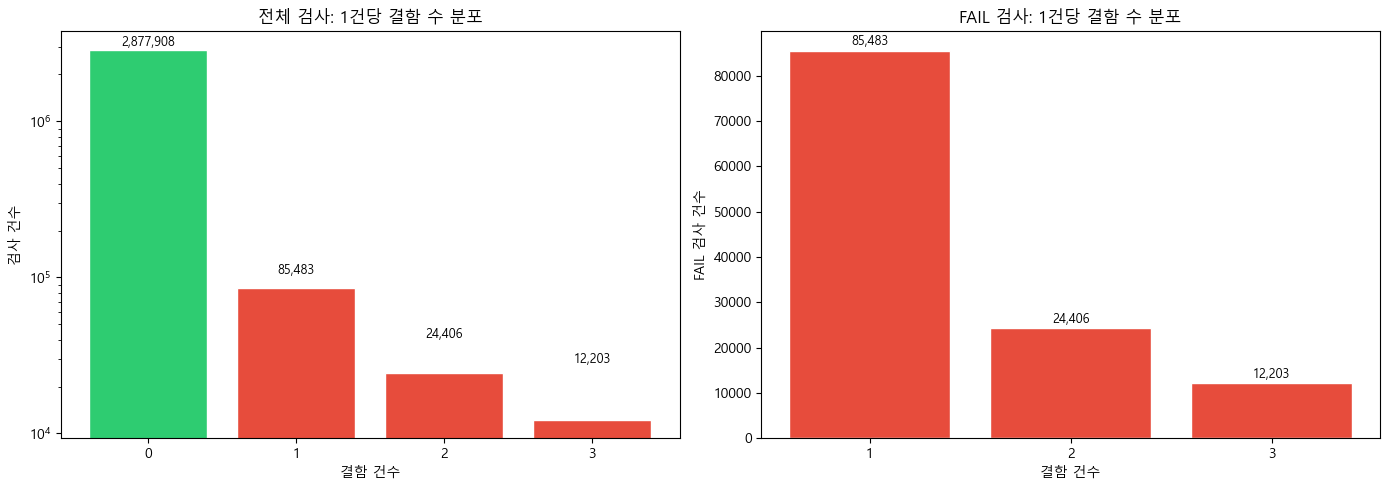

In [3]:
# inspection_id별 defect_detail 건수
defect_counts = defect.groupby('inspection_id').size().rename('defect_count')

# inspection_master에 조인
ins_with_cnt = ins.merge(defect_counts, left_on='inspection_id', right_index=True, how='left')
ins_with_cnt['defect_count'] = ins_with_cnt['defect_count'].fillna(0).astype(int)

# 분포 집계
dist = ins_with_cnt['defect_count'].value_counts().sort_index()
print('=== inspection_master 1건당 defect_detail 매칭 건수 분포 ===')
for cnt, freq in dist.items():
    pct = freq / len(ins) * 100
    print(f'  결함 {cnt}건: {freq:>10,}건 ({pct:.2f}%)')

# FAIL 건만 필터
fail_dist = ins_with_cnt[ins_with_cnt['result'] == 'FAIL']['defect_count'].value_counts().sort_index()
print(f'\n=== FAIL 건의 결함 수 분포 ===')
for cnt, freq in fail_dist.items():
    pct = freq / len(ins_with_cnt[ins_with_cnt['result'] == 'FAIL']) * 100
    print(f'  결함 {cnt}건: {freq:>10,}건 ({pct:.2f}%)')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 분포
colors_bar = ['#2ecc71' if i == 0 else '#e74c3c' for i in dist.index]
axes[0].bar(dist.index.astype(str), dist.values, color=colors_bar, edgecolor='white')
for i, (idx, v) in enumerate(zip(dist.index, dist.values)):
    axes[0].text(i, v + len(ins)*0.005, f'{v:,}', ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('결함 건수')
axes[0].set_ylabel('검사 건수')
axes[0].set_title('전체 검사: 1건당 결함 수 분포')
axes[0].set_yscale('log')

# FAIL만
axes[1].bar(fail_dist.index.astype(str), fail_dist.values, color='#e74c3c', edgecolor='white')
for i, (idx, v) in enumerate(zip(fail_dist.index, fail_dist.values)):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('결함 건수')
axes[1].set_ylabel('FAIL 검사 건수')
axes[1].set_title('FAIL 검사: 1건당 결함 수 분포')

plt.tight_layout()
plt.show()

### 1-2. PASS인데 defect_detail에 존재하는 케이스 (데이터 정합성)

=== 데이터 정합성 검증 ===
PASS 총 건수:                       2,877,908
PASS인데 defect_detail에 있는 건:            0
FAIL 총 건수:                         122,092
FAIL인데 defect_detail에 없는 건:            0

정합성 OK: PASS 검사에는 결함 레코드가 없음
정합성 OK: 모든 FAIL 검사에 결함 레코드 존재


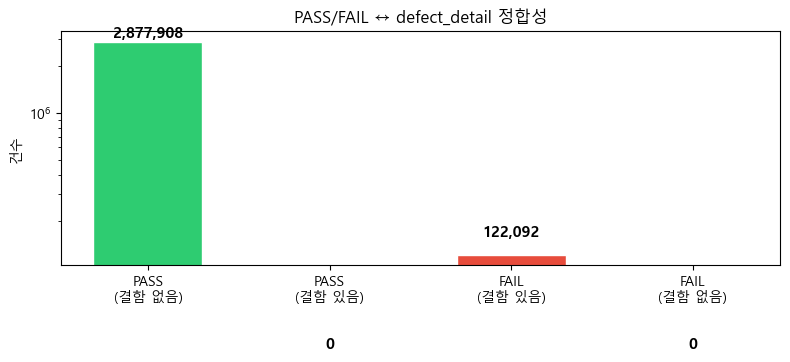

In [4]:
# PASS 검사 중 defect_detail에 존재하는 건
pass_ids = set(ins[ins['result'] == 'PASS']['inspection_id'])
defect_ids = set(defect['inspection_id'])
pass_with_defect = pass_ids & defect_ids

# FAIL 검사 중 defect_detail에 없는 건
fail_ids = set(ins[ins['result'] == 'FAIL']['inspection_id'])
fail_without_defect = fail_ids - defect_ids

print('=== 데이터 정합성 검증 ===')
print(f'PASS 총 건수:                      {len(pass_ids):>10,}')
print(f'PASS인데 defect_detail에 있는 건:   {len(pass_with_defect):>10,}')
print(f'FAIL 총 건수:                      {len(fail_ids):>10,}')
print(f'FAIL인데 defect_detail에 없는 건:   {len(fail_without_defect):>10,}')
print()

if pass_with_defect:
    sample = defect[defect['inspection_id'].isin(list(pass_with_defect)[:5])]
    print('PASS인데 결함이 있는 케이스 샘플:')
    display(sample[['defect_id','inspection_id','defect_type_name','severity','confidence']].head(10))
else:
    print('정합성 OK: PASS 검사에는 결함 레코드가 없음')

if fail_without_defect:
    print(f'\n주의: FAIL이지만 결함 레코드가 없는 건 {len(fail_without_defect):,}건')
else:
    print('정합성 OK: 모든 FAIL 검사에 결함 레코드 존재')

# 정합성 요약 시각화
fig, ax = plt.subplots(figsize=(8, 4))
categories = ['PASS\n(결함 없음)', 'PASS\n(결함 있음)', 'FAIL\n(결함 있음)', 'FAIL\n(결함 없음)']
values = [
    len(pass_ids) - len(pass_with_defect),
    len(pass_with_defect),
    len(fail_ids) - len(fail_without_defect),
    len(fail_without_defect)
]
bar_colors = ['#2ecc71', '#e67e22', '#e74c3c', '#e67e22']
bars = ax.bar(categories, values, color=bar_colors, edgecolor='white', width=0.6)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
            f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('건수')
ax.set_title('PASS/FAIL ↔ defect_detail 정합성')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### 1-3. daily_summary ↔ inspection_master 집계 샘플 검증

In [5]:
# inspection_master에서 직접 집계
ins['date'] = pd.to_datetime(ins['inspection_datetime']).dt.date.astype(str)
agg = ins.groupby(['date', 'plant_code', 'line_code', 'model_code', 'shift']).agg(
    calc_total=('inspection_id', 'count'),
    calc_pass=('result', lambda x: (x == 'PASS').sum()),
    calc_fail=('result', lambda x: (x == 'FAIL').sum()),
    calc_avg_inf=('inference_time_sec', 'mean'),
    calc_avg_takt=('takt_time_sec', 'mean'),
    calc_avg_conf=('confidence_score', 'mean'),
    calc_avg_temp=('ambient_temp_c', 'mean'),
    calc_avg_hum=('humidity_pct', 'mean')
).reset_index()

# daily_summary와 조인
comp = daily.merge(agg, on=['date', 'plant_code', 'line_code', 'model_code', 'shift'],
                   how='inner', suffixes=('_ds', '_calc'))

print(f'=== daily_summary ↔ inspection_master 집계 비교 ===')
print(f'daily_summary 행: {len(daily):,}  |  조인 매칭: {len(comp):,}  |  미매칭: {len(daily) - len(comp):,}')

# 주요 컬럼 일치 여부
checks = {
    'total_inspections': ('total_inspections', 'calc_total'),
    'pass_count': ('pass_count', 'calc_pass'),
    'fail_count': ('fail_count', 'calc_fail'),
}
print(f'\n--- 정수형 컬럼 정확 일치 검증 ---')
for name, (ds_col, calc_col) in checks.items():
    match = (comp[ds_col] == comp[calc_col]).sum()
    total = len(comp)
    print(f'  {name:25s}: {match:,}/{total:,} 일치 ({match/total*100:.2f}%)')

# 실수형 컬럼 오차 확인 (반올림 오차 허용)
float_checks = {
    'avg_inference_time': ('avg_inference_time', 'calc_avg_inf'),
    'avg_takt_time': ('avg_takt_time', 'calc_avg_takt'),
    'avg_confidence': ('avg_confidence', 'calc_avg_conf'),
    'avg_temp': ('avg_temp', 'calc_avg_temp'),
    'avg_humidity': ('avg_humidity', 'calc_avg_hum'),
}
print(f'\n--- 실수형 컬럼 오차 검증 (|diff| < 0.01 허용) ---')
for name, (ds_col, calc_col) in float_checks.items():
    diff = (comp[ds_col] - comp[calc_col]).abs()
    within = (diff < 0.01).sum()
    print(f'  {name:25s}: {within:,}/{len(comp):,} 허용범위 내 ({within/len(comp)*100:.2f}%)  '
          f'max_diff={diff.max():.6f}')

# yield_rate 검증
comp['calc_yield'] = comp['calc_pass'] / comp['calc_total'] * 100
yield_diff = (comp['yield_rate'] - comp['calc_yield']).abs()
print(f'  {"yield_rate":25s}: {(yield_diff < 0.1).sum():,}/{len(comp):,} 허용범위 내  '
      f'max_diff={yield_diff.max():.4f}')

=== daily_summary ↔ inspection_master 집계 비교 ===
daily_summary 행: 318,812  |  조인 매칭: 318,812  |  미매칭: 0

--- 정수형 컬럼 정확 일치 검증 ---
  total_inspections        : 318,812/318,812 일치 (100.00%)
  pass_count               : 318,812/318,812 일치 (100.00%)
  fail_count               : 318,812/318,812 일치 (100.00%)

--- 실수형 컬럼 오차 검증 (|diff| < 0.01 허용) ---
  avg_inference_time       : 318,812/318,812 허용범위 내 (100.00%)  max_diff=0.000000
  avg_takt_time            : 318,812/318,812 허용범위 내 (100.00%)  max_diff=0.000000
  avg_confidence           : 318,812/318,812 허용범위 내 (100.00%)  max_diff=0.000000
  avg_temp                 : 318,812/318,812 허용범위 내 (100.00%)  max_diff=0.000000
  avg_humidity             : 318,812/318,812 허용범위 내 (100.00%)  max_diff=0.000000
  yield_rate               : 318,812/318,812 허용범위 내  max_diff=0.0050


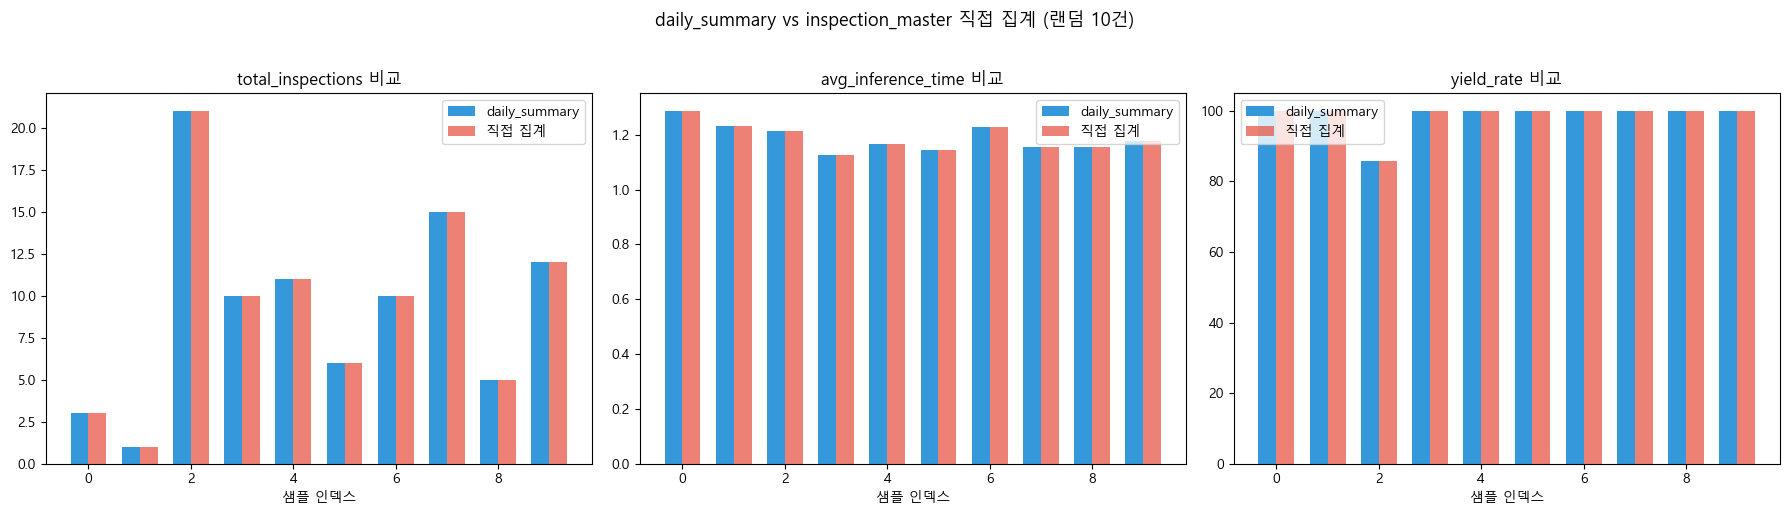

In [6]:
# 시각화: 랜덤 샘플 10건의 비교
sample_comp = comp.sample(10, random_state=42).sort_values('date')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = range(len(sample_comp))
w = 0.35

# total_inspections
axes[0].bar([i - w/2 for i in x], sample_comp['total_inspections'], w, label='daily_summary', color='#3498db')
axes[0].bar([i + w/2 for i in x], sample_comp['calc_total'], w, label='직접 집계', color='#e74c3c', alpha=0.7)
axes[0].set_title('total_inspections 비교')
axes[0].set_xlabel('샘플 인덱스')
axes[0].legend()

# avg_inference_time
axes[1].bar([i - w/2 for i in x], sample_comp['avg_inference_time'], w, label='daily_summary', color='#3498db')
axes[1].bar([i + w/2 for i in x], sample_comp['calc_avg_inf'], w, label='직접 집계', color='#e74c3c', alpha=0.7)
axes[1].set_title('avg_inference_time 비교')
axes[1].set_xlabel('샘플 인덱스')
axes[1].legend()

# yield_rate
axes[2].bar([i - w/2 for i in x], sample_comp['yield_rate'], w, label='daily_summary', color='#3498db')
axes[2].bar([i + w/2 for i in x], sample_comp['calc_yield'], w, label='직접 집계', color='#e74c3c', alpha=0.7)
axes[2].set_title('yield_rate 비교')
axes[2].set_xlabel('샘플 인덱스')
axes[2].legend()

plt.suptitle('daily_summary vs inspection_master 직접 집계 (랜덤 10건)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. 마스터 테이블별 실제 분포

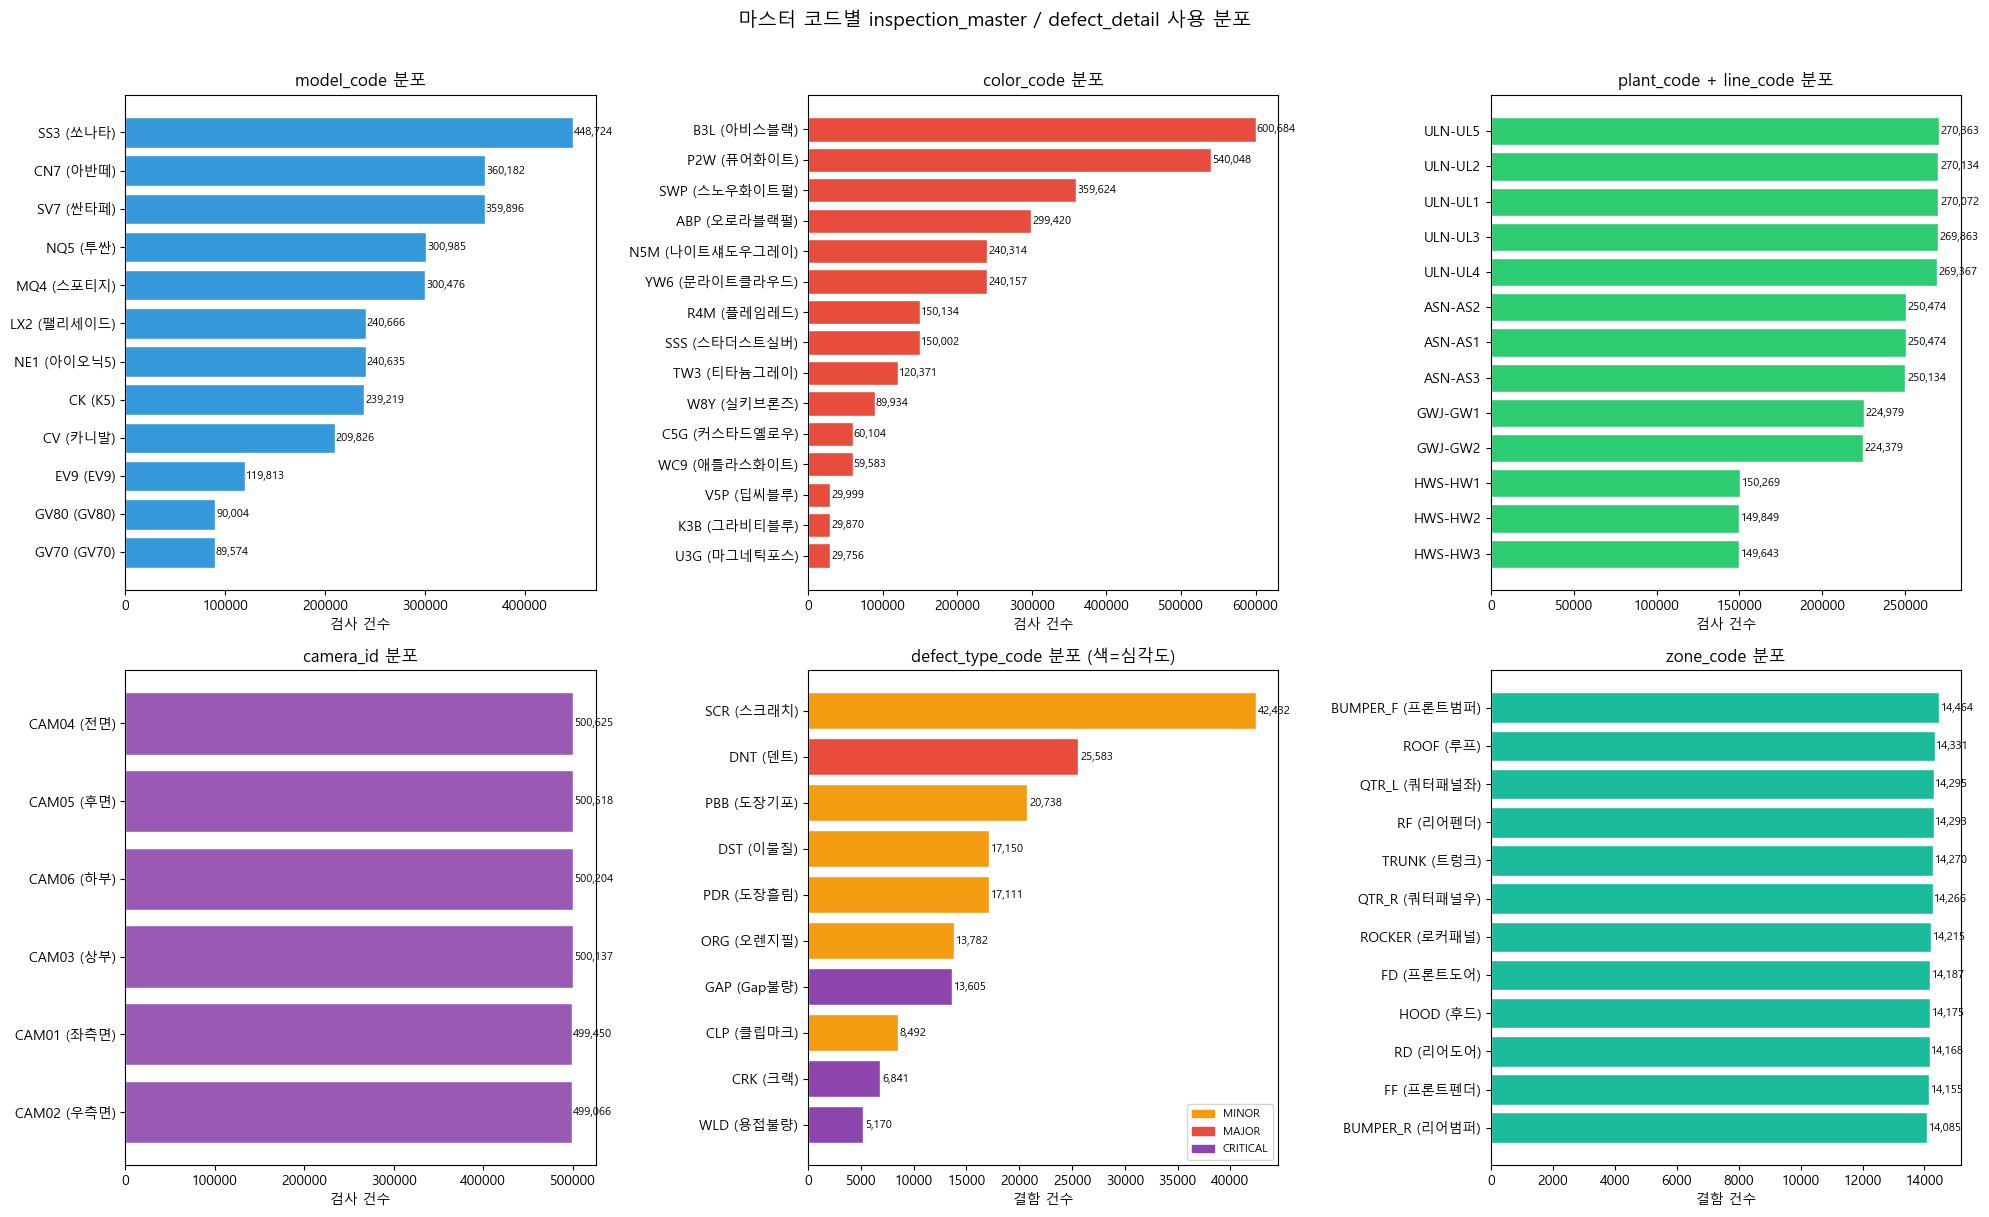


=== 쏠림 분석 요약 ===


  model_code     : CV=45.0%, max/min=5.01x
  color_code     : CV=91.1%, max/min=20.19x
  camera_id      : CV=0.1%, max/min=1.00x


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ── 2-1. model_code ──
ax = axes[0, 0]
model_dist = ins['model_code'].value_counts().sort_values(ascending=True)
model_labels = [f"{code} ({m_model[m_model['model_code']==code]['model_name'].values[0]})"
                if code in m_model['model_code'].values else code
                for code in model_dist.index]
bars = ax.barh(model_labels, model_dist.values, color='#3498db', edgecolor='white')
for bar, v in zip(bars, model_dist.values):
    ax.text(v + 1000, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center', fontsize=8)
ax.set_title('model_code 분포')
ax.set_xlabel('검사 건수')

# ── 2-2. color_code ──
ax = axes[0, 1]
color_dist = ins['color_code'].value_counts().sort_values(ascending=True)
color_labels = [f"{code} ({m_color[m_color['color_code']==code]['color_name'].values[0]})"
                if code in m_color['color_code'].values else code
                for code in color_dist.index]
bars = ax.barh(color_labels, color_dist.values, color='#e74c3c', edgecolor='white')
for bar, v in zip(bars, color_dist.values):
    ax.text(v + 1000, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center', fontsize=8)
ax.set_title('color_code 분포')
ax.set_xlabel('검사 건수')

# ── 2-3. plant_code + line_code ──
ax = axes[0, 2]
plant_line_dist = ins.groupby(['plant_code', 'line_code']).size().sort_values(ascending=True)
pl_labels = [f'{p}-{l}' for p, l in plant_line_dist.index]
bars = ax.barh(pl_labels, plant_line_dist.values, color='#2ecc71', edgecolor='white')
for bar, v in zip(bars, plant_line_dist.values):
    ax.text(v + 1000, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center', fontsize=8)
ax.set_title('plant_code + line_code 분포')
ax.set_xlabel('검사 건수')

# ── 2-4. camera_id ──
ax = axes[1, 0]
cam_dist = ins['camera_id'].value_counts().sort_values(ascending=True)
cam_labels = [f"{cid} ({m_camera[m_camera['camera_id']==cid]['position'].values[0]})"
              if cid in m_camera['camera_id'].values else cid
              for cid in cam_dist.index]
bars = ax.barh(cam_labels, cam_dist.values, color='#9b59b6', edgecolor='white')
for bar, v in zip(bars, cam_dist.values):
    ax.text(v + 1000, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center', fontsize=8)
ax.set_title('camera_id 분포')
ax.set_xlabel('검사 건수')

# ── 2-5. defect_type (defect_detail 기준) ──
ax = axes[1, 1]
dt_dist = defect['defect_type_code'].value_counts().sort_values(ascending=True)
dt_labels = [f"{code} ({m_defect[m_defect['defect_type_code']==code]['defect_type_name'].values[0]})"
             if code in m_defect['defect_type_code'].values else code
             for code in dt_dist.index]
sev_colors = {'MINOR': '#f39c12', 'MAJOR': '#e74c3c', 'CRITICAL': '#8e44ad'}
bar_colors = [sev_colors.get(m_defect[m_defect['defect_type_code']==code]['severity'].values[0], '#95a5a6')
              if code in m_defect['defect_type_code'].values else '#95a5a6'
              for code in dt_dist.index]
bars = ax.barh(dt_labels, dt_dist.values, color=bar_colors, edgecolor='white')
for bar, v in zip(bars, dt_dist.values):
    ax.text(v + 200, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center', fontsize=8)
ax.set_title('defect_type_code 분포 (색=심각도)')
ax.set_xlabel('결함 건수')
legend_patches = [mpatches.Patch(color=c, label=s) for s, c in sev_colors.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)

# ── 2-6. zone_code (defect_detail 기준) ──
ax = axes[1, 2]
zone_dist = defect['zone_code'].value_counts().sort_values(ascending=True)
zone_labels = [f"{code} ({m_zone[m_zone['zone_code']==code]['zone_name'].values[0]})"
               if code in m_zone['zone_code'].values else code
               for code in zone_dist.index]
bars = ax.barh(zone_labels, zone_dist.values, color='#1abc9c', edgecolor='white')
for bar, v in zip(bars, zone_dist.values):
    ax.text(v + 50, bar.get_y() + bar.get_height()/2, f'{v:,}', va='center', fontsize=8)
ax.set_title('zone_code 분포')
ax.set_xlabel('결함 건수')

plt.suptitle('마스터 코드별 inspection_master / defect_detail 사용 분포', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 쏠림 분석 요약
print('\n=== 쏠림 분석 요약 ===')
for name, dist_s in [('model_code', ins['model_code'].value_counts()),
                     ('color_code', ins['color_code'].value_counts()),
                     ('camera_id', ins['camera_id'].value_counts())]:
    cv = dist_s.std() / dist_s.mean() * 100
    ratio = dist_s.max() / dist_s.min()
    print(f'  {name:15s}: CV={cv:.1f}%, max/min={ratio:.2f}x')

---
## 3. 키 연결 시각화 (ER 다이어그램 + 카디널리티)

In [8]:
# ── 카디널리티 분석 ──
cardinality = {}

# inspection_master → master_model (N:1)
cardinality['ins → m_model'] = f"N:1 ({len(ins):,} → {ins['model_code'].nunique()})"
# inspection_master → master_color (N:1)
cardinality['ins → m_color'] = f"N:1 ({len(ins):,} → {ins['color_code'].nunique()})"
# inspection_master → master_plant_line (N:1)
cardinality['ins → m_plant_line'] = f"N:1 ({len(ins):,} → {ins.groupby(['plant_code','line_code']).ngroups})"
# inspection_master → master_camera (N:1)
cardinality['ins → m_camera'] = f"N:1 ({len(ins):,} → {ins['camera_id'].nunique()})"
# inspection_master → defect_detail (1:N)
fail_with_defect = ins_with_cnt[ins_with_cnt['defect_count'] > 0]
avg_defects = fail_with_defect['defect_count'].mean()
cardinality['ins → defect_detail'] = f"1:N (평균 1:{avg_defects:.1f}, max 1:{ins_with_cnt['defect_count'].max()})"
# defect_detail → master_defect_type (N:1)
cardinality['defect → m_defect_type'] = f"N:1 ({len(defect):,} → {defect['defect_type_code'].nunique()})"
# defect_detail → master_zone (N:1)
cardinality['defect → m_zone'] = f"N:1 ({len(defect):,} → {defect['zone_code'].nunique()})"
# daily_summary → master_model (N:1)
cardinality['daily → m_model'] = f"N:1 ({len(daily):,} → {daily['model_code'].nunique()})"
# daily_summary → master_plant_line (N:1)
cardinality['daily → m_plant_line'] = f"N:1 ({len(daily):,} → {daily.groupby(['plant_code','line_code']).ngroups})"

print('=== 카디널리티 분석 ===')
for rel, card in cardinality.items():
    print(f'  {rel:30s}  {card}')

=== 카디널리티 분석 ===
  ins → m_model                   N:1 (3,000,000 → 12)
  ins → m_color                   N:1 (3,000,000 → 15)
  ins → m_plant_line              N:1 (3,000,000 → 13)
  ins → m_camera                  N:1 (3,000,000 → 6)
  ins → defect_detail             1:N (평균 1:1.4, max 1:3)
  defect → m_defect_type          N:1 (170,904 → 10)
  defect → m_zone                 N:1 (170,904 → 12)
  daily → m_model                 N:1 (318,812 → 12)
  daily → m_plant_line            N:1 (318,812 → 13)


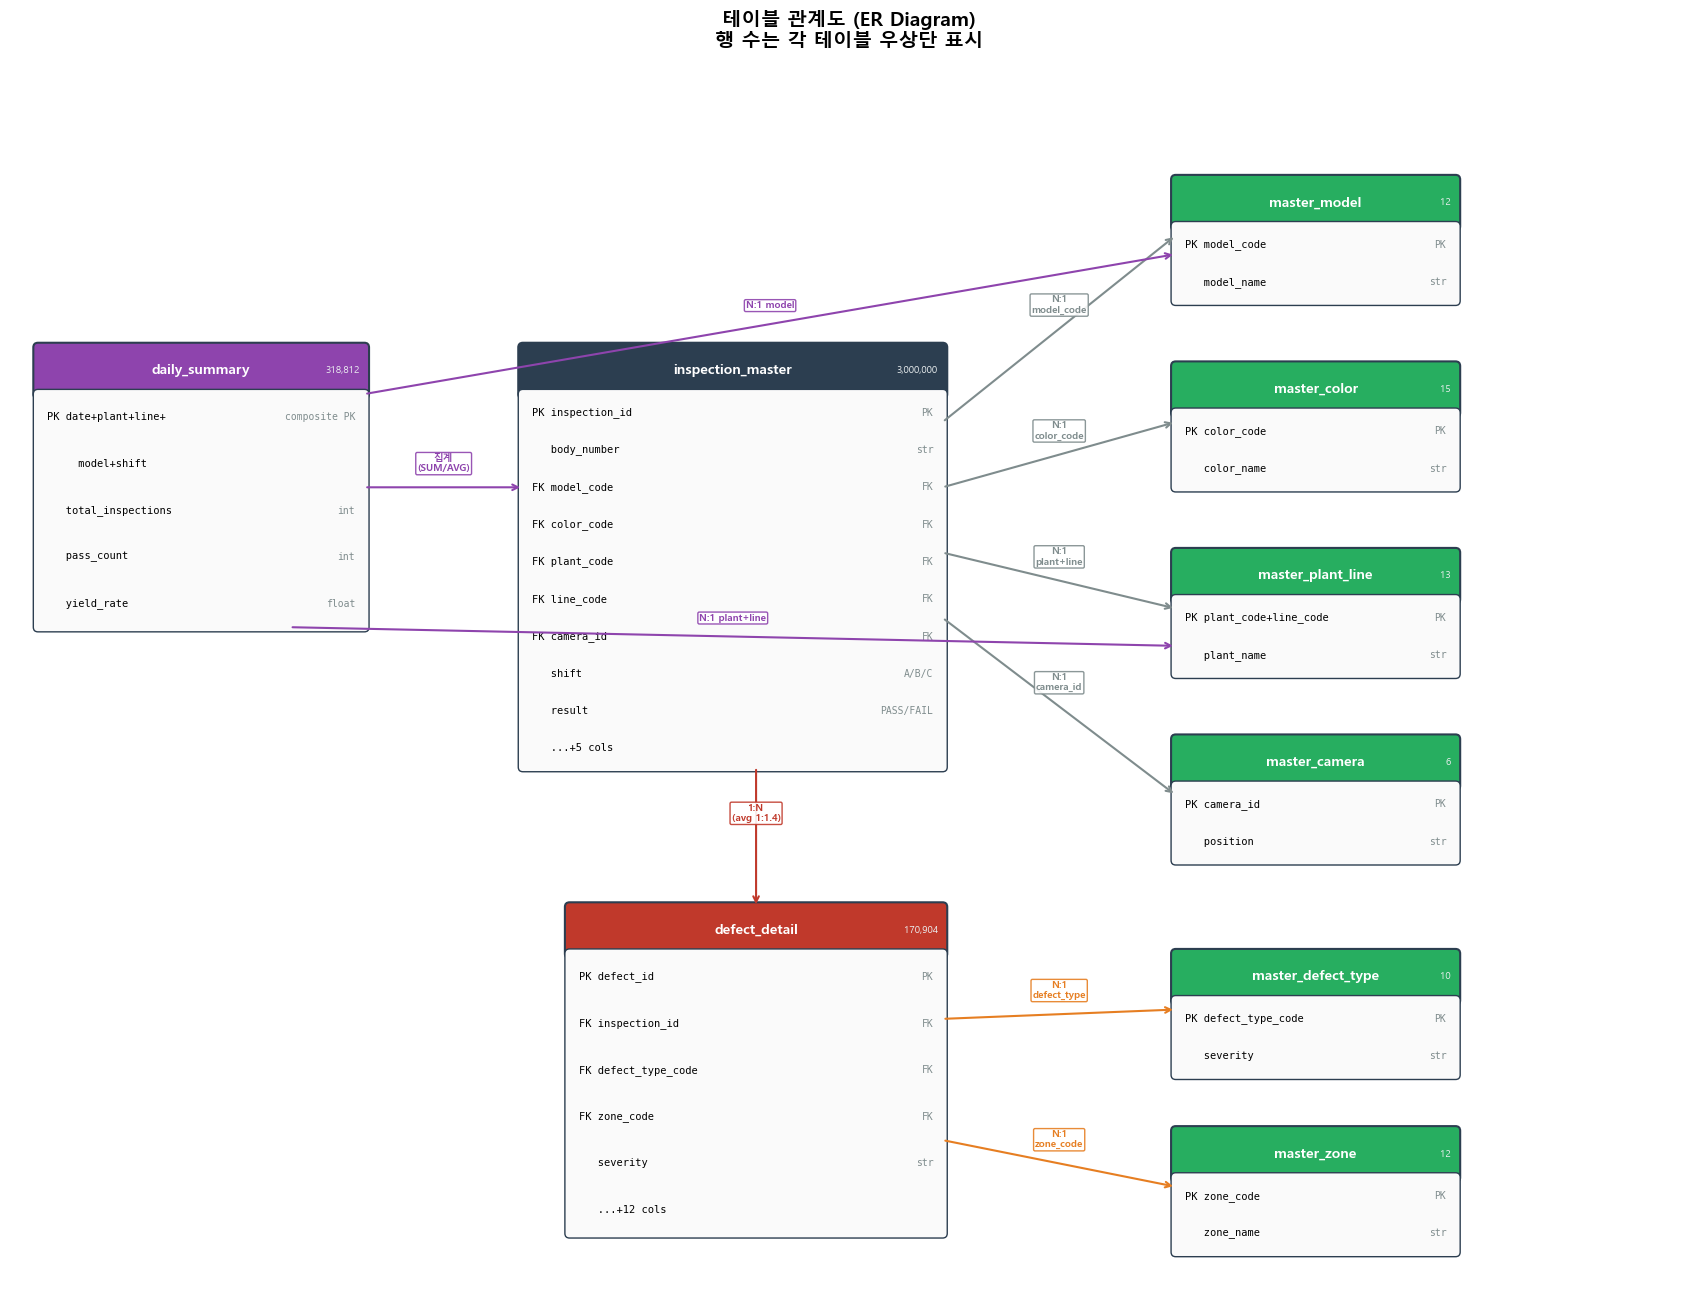

In [9]:
# ── ER 다이어그램 시각화 ──
fig, ax = plt.subplots(figsize=(18, 13))
ax.set_xlim(0, 18)
ax.set_ylim(0, 13)
ax.set_aspect('equal')
ax.axis('off')

def draw_table(ax, x, y, w, h, title, fields, color, rows=None):
    """테이블 박스 그리기"""
    # 헤더
    header_h = 0.5
    rect = mpatches.FancyBboxPatch((x, y+h-header_h), w, header_h,
                                    boxstyle='round,pad=0.05', facecolor=color,
                                    edgecolor='#2c3e50', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h-header_h/2, title, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    if rows:
        ax.text(x+w-0.05, y+h-header_h/2, f'{rows}', ha='right', va='center',
                fontsize=7, color='#ecf0f1')
    # 바디
    body = mpatches.FancyBboxPatch((x, y), w, h-header_h,
                                   boxstyle='round,pad=0.05', facecolor='#fafafa',
                                   edgecolor='#2c3e50', linewidth=1)
    ax.add_patch(body)
    line_h = (h - header_h) / max(len(fields), 1)
    for i, (fname, ftype) in enumerate(fields):
        fy = y + h - header_h - (i+0.5)*line_h
        prefix = 'PK ' if i == 0 else 'FK ' if 'FK' in ftype else '   '
        ax.text(x+0.1, fy, f'{prefix}{fname}', fontsize=7.5, va='center', fontfamily='monospace')
        ax.text(x+w-0.1, fy, ftype.replace('FK ',''), fontsize=7, va='center', ha='right',
                color='#7f8c8d', fontfamily='monospace')

# ── 테이블 위치 및 정의 ──
# 중앙 - inspection_master
draw_table(ax, 5.5, 5.5, 4.5, 4.5, 'inspection_master', [
    ('inspection_id', 'PK'),
    ('body_number', 'str'),
    ('model_code', 'FK'),
    ('color_code', 'FK'),
    ('plant_code', 'FK'),
    ('line_code', 'FK'),
    ('camera_id', 'FK'),
    ('shift', 'A/B/C'),
    ('result', 'PASS/FAIL'),
    ('...+5 cols', ''),
], '#2c3e50', '3,000,000')

# 하단 - defect_detail
draw_table(ax, 6, 0.5, 4, 3.5, 'defect_detail', [
    ('defect_id', 'PK'),
    ('inspection_id', 'FK'),
    ('defect_type_code', 'FK'),
    ('zone_code', 'FK'),
    ('severity', 'str'),
    ('...+12 cols', ''),
], '#c0392b', '170,904')

# 좌측 상단 - daily_summary
draw_table(ax, 0.3, 7, 3.5, 3, 'daily_summary', [
    ('date+plant+line+', 'composite PK'),
    ('  model+shift', ''),
    ('total_inspections', 'int'),
    ('pass_count', 'int'),
    ('yield_rate', 'float'),
], '#8e44ad', '318,812')

# 우측 마스터들
draw_table(ax, 12.5, 10.5, 3, 1.3, 'master_model', [
    ('model_code', 'PK'),
    ('model_name', 'str'),
], '#27ae60', '12')

draw_table(ax, 12.5, 8.5, 3, 1.3, 'master_color', [
    ('color_code', 'PK'),
    ('color_name', 'str'),
], '#27ae60', '15')

draw_table(ax, 12.5, 6.5, 3, 1.3, 'master_plant_line', [
    ('plant_code+line_code', 'PK'),
    ('plant_name', 'str'),
], '#27ae60', '13')

draw_table(ax, 12.5, 4.5, 3, 1.3, 'master_camera', [
    ('camera_id', 'PK'),
    ('position', 'str'),
], '#27ae60', '6')

draw_table(ax, 12.5, 2.2, 3, 1.3, 'master_defect_type', [
    ('defect_type_code', 'PK'),
    ('severity', 'str'),
], '#27ae60', '10')

draw_table(ax, 12.5, 0.3, 3, 1.3, 'master_zone', [
    ('zone_code', 'PK'),
    ('zone_name', 'str'),
], '#27ae60', '12')

# ── 관계선 ──
def draw_rel(ax, x1, y1, x2, y2, label, color='#7f8c8d'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    mx, my = (x1+x2)/2, (y1+y2)/2
    ax.text(mx, my+0.15, label, fontsize=7, ha='center', va='bottom',
            color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=color, alpha=0.9))

# ins → masters (우측)
draw_rel(ax, 10, 9.2, 12.5, 11.2, 'N:1\nmodel_code')
draw_rel(ax, 10, 8.5, 12.5, 9.2, 'N:1\ncolor_code')
draw_rel(ax, 10, 7.8, 12.5, 7.2, 'N:1\nplant+line')
draw_rel(ax, 10, 7.1, 12.5, 5.2, 'N:1\ncamera_id')

# ins → defect_detail (하단)
draw_rel(ax, 8, 5.5, 8, 4.0, f'1:N\n(avg 1:{avg_defects:.1f})', '#c0392b')

# defect → masters
draw_rel(ax, 10, 2.8, 12.5, 2.9, 'N:1\ndefect_type', '#e67e22')
draw_rel(ax, 10, 1.5, 12.5, 1.0, 'N:1\nzone_code', '#e67e22')

# daily_summary → ins (집계 관계)
draw_rel(ax, 3.8, 8.5, 5.5, 8.5, '집계\n(SUM/AVG)', '#8e44ad')

# daily → masters
draw_rel(ax, 3.8, 9.5, 12.5, 11.0, 'N:1 model', '#8e44ad')
draw_rel(ax, 3.0, 7.0, 12.5, 6.8, 'N:1 plant+line', '#8e44ad')

ax.set_title('테이블 관계도 (ER Diagram)\n행 수는 각 테이블 우상단 표시', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 4. 이미지-정형 데이터 연결 가능성

### 4-1. 이미지 파일명에서 zone, color 추출 → 정형 데이터 매칭

In [10]:
import re

# 이미지 파일명 수집
img_files = list((IMG_DIR / 'images' / 'train').glob('*.jpg')) + \
            list((IMG_DIR / 'images' / 'val').glob('*.jpg'))
print(f'총 이미지 파일: {len(img_files)}장 (train+val)')

# 파일명 파싱: {zone}_{color}_{id}.jpg
# zone: bumper, fender, front_door, rear_door, hood, roof, trunk, rocker
# color: black, blue, bronze, gray, green, navy, pearl_white, red, silver, white
ZONE_PATTERN = r'^(bumper|fender|front_door|rear_door|hood|roof|trunk|rocker)'
parsed = []
for f in img_files:
    name = f.stem  # e.g. bumper_black_000001
    m = re.match(ZONE_PATTERN, name)
    if m:
        zone_img = m.group(1)
        rest = name[m.end()+1:]  # black_000001
        parts = rest.rsplit('_', 1)  # ['black', '000001'] or ['pearl_white', '000001']
        color_img = parts[0]
        img_id = parts[1] if len(parts) > 1 else ''
        parsed.append({'file': f.name, 'zone_img': zone_img, 'color_img': color_img, 'img_id': img_id})

img_df = pd.DataFrame(parsed)
print(f'파싱 성공: {len(img_df)}/{len(img_files)}\n')

# zone 매핑 분석
img_zones = sorted(img_df['zone_img'].unique())
master_zones = sorted(m_zone['zone_code'].values)

zone_mapping = {
    'hood': ['HOOD'],
    'fender': ['FF', 'RF'],
    'front_door': ['FD'],
    'rear_door': ['RD'],
    'bumper': ['BUMPER_F', 'BUMPER_R'],
    'roof': ['ROOF'],
    'trunk': ['TRUNK'],
    'rocker': ['ROCKER'],
}

print('=== 이미지 zone → master_zone 매핑 ===')
print(f'{"이미지 zone":15s} → {"master_zone":25s} 매핑 유형')
print('-'*60)
for z_img in img_zones:
    targets = zone_mapping.get(z_img, ['?'])
    map_type = '1:1 (정확)' if len(targets) == 1 else f'1:{len(targets)} (모호)'
    print(f'{z_img:15s} → {", ".join(targets):25s} {map_type}')

# 이미지에 없는 master_zone
covered = set()
for targets in zone_mapping.values():
    covered.update(targets)
uncovered = set(master_zones) - covered
print(f'\n이미지에 대응 없는 master_zone: {uncovered if uncovered else "없음"}')

총 이미지 파일: 1000장 (train+val)
파싱 성공: 1000/1000

=== 이미지 zone → master_zone 매핑 ===
이미지 zone        → master_zone               매핑 유형
------------------------------------------------------------
bumper          → BUMPER_F, BUMPER_R        1:2 (모호)
fender          → FF, RF                    1:2 (모호)
front_door      → FD                        1:1 (정확)
hood            → HOOD                      1:1 (정확)
rear_door       → RD                        1:1 (정확)
rocker          → ROCKER                    1:1 (정확)
roof            → ROOF                      1:1 (정확)
trunk           → TRUNK                     1:1 (정확)

이미지에 대응 없는 master_zone: {'QTR_R', 'QTR_L'}


=== 이미지 color → master_color 매핑 ===
이미지 color       → 후보 master_color                          매핑 유형
---------------------------------------------------------------------------
black           → B3L (아비스블랙)                              1:1 (추정 가능)
blue            → Y7B (아틀란티스블루), NB5 (인텐스블루)               1:2 (모호)
bronze          → ?                                        매핑 불가
gray            → AGT (어비스그레이), TGN (그라비티골드)               1:2 (모호)
green           → ?                                        매핑 불가
navy            → NB5 (인텐스블루)                              1:1 (추정 가능)
pearl_white     → SWP (스노우화이트펄)                            1:1 (추정 가능)
red             → R4M (플레임레드)                              1:1 (추정 가능)
silver          → R9S (타이타늄실버), KLG (시어실버)                 1:2 (모호)
white           → P2W (퓨어화이트), SWP (스노우화이트펄)               1:2 (모호)


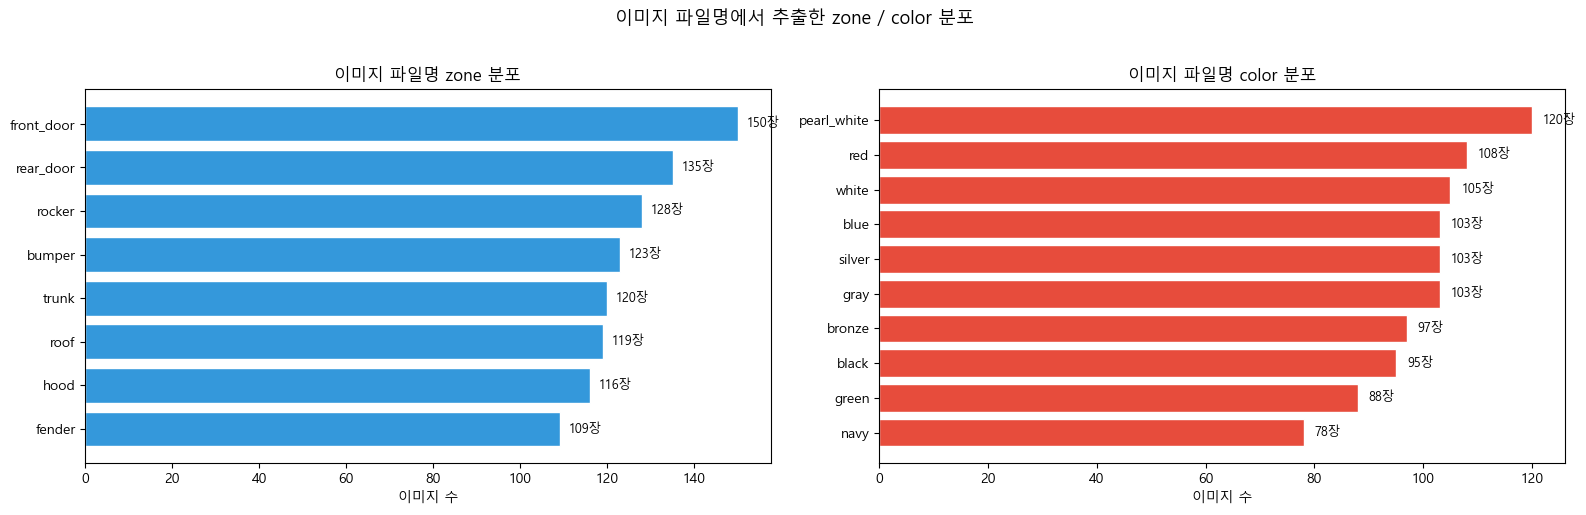

In [11]:
# color 매핑 분석
img_colors = sorted(img_df['color_img'].unique())
master_colors = m_color[['color_code', 'color_name']].values.tolist()

# 가능한 매핑 (이미지 영문 → 마스터 코드)
color_mapping_candidates = {
    'black': ['B3L (아비스블랙)'],
    'white': ['P2W (퓨어화이트)', 'SWP (스노우화이트펄)'],
    'pearl_white': ['SWP (스노우화이트펄)'],
    'red': ['R4M (플레임레드)'],
    'blue': ['Y7B (아틀란티스블루)', 'NB5 (인텐스블루)'],
    'silver': ['R9S (타이타늄실버)', 'KLG (시어실버)'],
    'gray': ['AGT (어비스그레이)', 'TGN (그라비티골드)'],
    'green': ['?'],
    'navy': ['NB5 (인텐스블루)'],
    'bronze': ['?'],
}

print('=== 이미지 color → master_color 매핑 ===')
print(f'{"이미지 color":15s} → {"후보 master_color":40s} 매핑 유형')
print('-'*75)
for c_img in img_colors:
    candidates = color_mapping_candidates.get(c_img, ['?'])
    if len(candidates) == 1 and candidates[0] != '?':
        map_type = '1:1 (추정 가능)'
    elif candidates[0] == '?':
        map_type = '매핑 불가'
    else:
        map_type = f'1:{len(candidates)} (모호)'
    print(f'{c_img:15s} → {", ".join(candidates):40s} {map_type}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# zone 분포
zone_counts = img_df['zone_img'].value_counts().sort_values(ascending=True)
bars = axes[0].barh(zone_counts.index, zone_counts.values, color='#3498db', edgecolor='white')
for bar, v in zip(bars, zone_counts.values):
    mapping_info = zone_mapping.get(bar.get_y(), ['?'])
    axes[0].text(v+2, bar.get_y() + bar.get_height()/2,
                 f'{v}장', va='center', fontsize=9)
axes[0].set_title('이미지 파일명 zone 분포')
axes[0].set_xlabel('이미지 수')

# color 분포
color_counts = img_df['color_img'].value_counts().sort_values(ascending=True)
bars = axes[1].barh(color_counts.index, color_counts.values, color='#e74c3c', edgecolor='white')
for bar, v in zip(bars, color_counts.values):
    axes[1].text(v+2, bar.get_y() + bar.get_height()/2,
                 f'{v}장', va='center', fontsize=9)
axes[1].set_title('이미지 파일명 color 분포')
axes[1].set_xlabel('이미지 수')

plt.suptitle('이미지 파일명에서 추출한 zone / color 분포', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4-2. YOLO class_id ↔ master_defect_type 매핑

In [12]:
# ── YOLO 라벨 파싱 ──
label_dirs = [IMG_DIR / 'labels' / 'train', IMG_DIR / 'labels' / 'val']
all_labels = []
empty_count = 0
for ldir in label_dirs:
    for lf in ldir.glob('*.txt'):
        content = lf.read_text().strip()
        if not content:
            empty_count += 1
            continue
        for line in content.split('\n'):
            parts = line.strip().split()
            if len(parts) >= 5:
                all_labels.append({
                    'file': lf.stem,
                    'class_id': int(parts[0]),
                })

label_df = pd.DataFrame(all_labels)

# ── data.yaml 기반 class_id → defect_type 매핑 ──
# YOLO 영문명 → master_defect_type_code
YOLO_TO_DEFECT = {
    'scratch':      'SCR',
    'dent':         'DNT',
    'paint_bubble': 'PBB',
    'paint_drip':   'PDR',
    'dust':         'DST',
    'orange_peel':  'ORG',
    'crack':        'CRK',
    'gap_fault':    'GAP',
}

yolo_names = data_yaml['names']  # {0: 'scratch', 1: 'dent', ...}
mapping_rows = []
for cid, yolo_name in yolo_names.items():
    defect_code = YOLO_TO_DEFECT.get(yolo_name, '?')
    defect_name_arr = m_defect[m_defect['defect_type_code']==defect_code]['defect_type_name'].values
    defect_name = defect_name_arr[0] if len(defect_name_arr) else '?'
    severity_arr = m_defect[m_defect['defect_type_code']==defect_code]['severity'].values
    severity = severity_arr[0] if len(severity_arr) else '?'
    cnt = (label_df['class_id']==cid).sum()
    mapping_rows.append({
        'class_id': cid,
        'yolo_name': yolo_name,
        'defect_type_code': defect_code,
        'defect_type_name': defect_name,
        'severity': severity,
        'bbox_count': cnt,
    })

mapping_df = pd.DataFrame(mapping_rows)
print('=== data.yaml 기반 class_id ↔ master_defect_type 매핑 ===')
print(mapping_df.to_string(index=False))

# 이미지에 없는 defect_type
all_codes = set(m_defect['defect_type_code'])
mapped_codes = set(mapping_df['defect_type_code']) - {'?'}
missing_codes = all_codes - mapped_codes
missing_df = m_defect[m_defect['defect_type_code'].isin(missing_codes)]
print(f'\n이미지 데이터에 없는 defect_type: {len(missing_codes)}개')
for _, row in missing_df.iterrows():
    print(f'  - {row["defect_type_code"]} ({row["defect_type_name"]}) - {row["severity"]}')

print(f'\n매핑 커버리지: {len(mapped_codes)}/{len(all_codes)} = {len(mapped_codes)/len(all_codes)*100:.1f}%')
print(f'YOLO 라벨 총 바운딩 박스: {len(label_df)}개, 빈 라벨 파일: {empty_count}개')


=== data.yaml 기반 class_id ↔ master_defect_type 매핑 ===
 class_id    yolo_name defect_type_code defect_type_name severity  bbox_count
        0      scratch              SCR             스크래치    MINOR         325
        1         dent              DNT               덴트    MAJOR         252
        2 paint_bubble              PBB             도장기포    MINOR         166
        3   paint_drip              PDR             도장흘림    MINOR         116
        4         dust              DST              이물질    MINOR         151
        5  orange_peel              ORG             오렌지필    MINOR         121
        6        crack              CRK               크랙 CRITICAL          54
        7    gap_fault              GAP            Gap불량 CRITICAL          99

이미지 데이터에 없는 defect_type: 2개
  - CLP (클립마크) - MINOR
  - WLD (용접불량) - CRITICAL

매핑 커버리지: 8/10 = 80.0%
YOLO 라벨 총 바운딩 박스: 1284개, 빈 라벨 파일: 169개


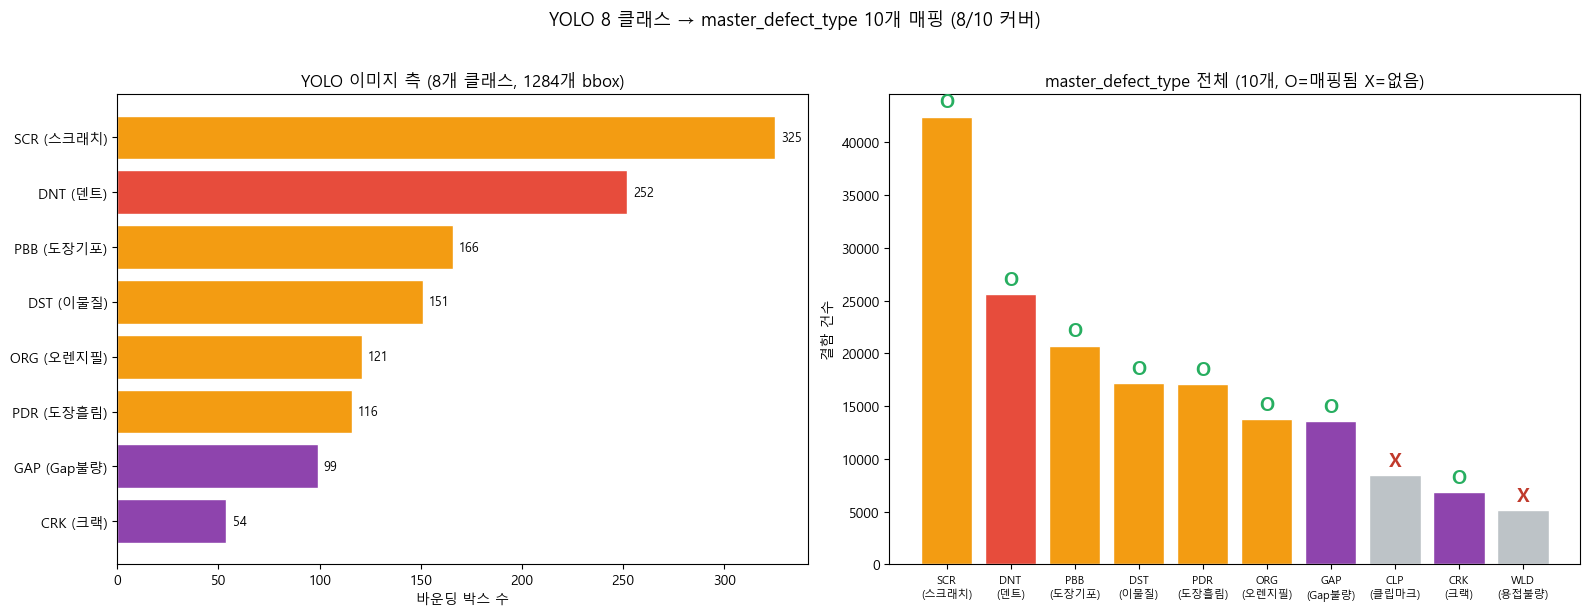

In [13]:
# ── YOLO class_id ↔ master_defect_type 매핑 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sev_colors = {'MINOR': '#f39c12', 'MAJOR': '#e74c3c', 'CRITICAL': '#8e44ad'}

# 좌: YOLO bbox 건수 (매핑된 이름으로)
mapping_df_sorted = mapping_df.sort_values('bbox_count', ascending=True)
labels_yolo = [f"{r['defect_type_code']} ({r['defect_type_name']})" for _, r in mapping_df_sorted.iterrows()]
bar_colors = [sev_colors.get(s, '#95a5a6') for s in mapping_df_sorted['severity']]
bars = axes[0].barh(labels_yolo, mapping_df_sorted['bbox_count'], color=bar_colors, edgecolor='white')
for bar, v in zip(bars, mapping_df_sorted['bbox_count']):
    axes[0].text(v+3, bar.get_y()+bar.get_height()/2, f'{v}', va='center', fontsize=9)
axes[0].set_title(f'YOLO 이미지 측 (8개 클래스, {len(label_df)}개 bbox)')
axes[0].set_xlabel('바운딩 박스 수')

# 우: master_defect_type 전체 - 매핑된 건 강조, 없는 건 회색
dt_order = defect['defect_type_code'].value_counts()
bar_colors_full = []
for code in dt_order.index:
    if code in mapped_codes:
        sev = m_defect[m_defect['defect_type_code']==code]['severity'].values[0]
        bar_colors_full.append(sev_colors.get(sev, '#95a5a6'))
    else:
        bar_colors_full.append('#bdc3c7')

bars = axes[1].bar(range(len(dt_order)), dt_order.values, color=bar_colors_full, edgecolor='white')
for i, (bar, v, code) in enumerate(zip(bars, dt_order.values, dt_order.index)):
    mapped = code in mapped_codes
    marker = 'O' if mapped else 'X'
    axes[1].text(bar.get_x()+bar.get_width()/2, v+500, marker,
                 ha='center', va='bottom', fontsize=14,
                 color='#27ae60' if mapped else '#c0392b', fontweight='bold')
axes[1].set_xticks(range(len(dt_order)))
dt_labels_x = [f"{code}\n({m_defect[m_defect['defect_type_code']==code]['defect_type_name'].values[0]})"
             for code in dt_order.index]
axes[1].set_xticklabels(dt_labels_x, fontsize=8)
axes[1].set_ylabel('결함 건수')
axes[1].set_title(f'master_defect_type 전체 ({len(m_defect)}개, O=매핑됨 X=없음)')

plt.suptitle('YOLO 8 클래스 → master_defect_type 10개 매핑 (8/10 커버)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 4-3. 연결 가능성 종합 매트릭스

In [14]:
# ── 종합 매핑 가능성 매트릭스 (data.yaml 반영) ──
summary_data = {
    '연결 시도': [
        'YOLO class_id → master_defect_type',
        '이미지 zone → master_zone',
        '이미지 color → master_color',
        '이미지 → inspection_master',
        '이미지 → defect_detail',
    ],
    '이미지 측': [
        f'data.yaml 8개 클래스',
        f'metadata.json 8개 zone',
        f'metadata.json 10개 color',
        f'파일명 (zone+color+id)',
        f'바운딩박스 {len(label_df)}개',
    ],
    '정형 측': [
        f'{len(m_defect)}개 defect_type',
        f'{len(m_zone)}개 zone_code',
        f'{len(m_color)}개 color_code',
        f'inspection_id 기반',
        f'defect_id + mm 좌표',
    ],
    '매핑 가능성': [
        'data.yaml 기반 8/10 명시 매핑 (CLP, WLD 제외)',
        '6/8 정확, bumper/fender 앞뒤 구분 불가, QTR 없음',
        '4/10 추정 가능, 4개 모호, bronze/green 매핑 불가',
        '공유 키(inspection_id) 없음',
        '좌표 체계 상이 (정규화 vs mm)',
    ],
    '상태': ['명시 가능', '부분 가능', '추정 필요', '불가', '불가']
}
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print('\n=== 핵심 발견사항 (수정) ===')
print('1. YOLO class_id 매 master_defect_type:')
print('   data.yaml에 명시적 매핑 존재. 8개 YOLO 클래스 전부 1:1 매핑 가능')
print('   (scratch→SCR, dent→DNT, paint_bubble→PBB, paint_drip→PDR,')
print('    dust→DST, orange_peel→ORG, crack→CRK, gap_fault→GAP)')
print('   CLP(클립마크), WLD(용접불량)만 이미지 데이터에 없음')
print()
print('2. 이미지-정형 인스턴스 레벨 조인 불가:')
print('   공유 키(inspection_id, body_number) 부재')
print('   → 이미지는 YOLO 검출 모델 학습/검증, 정형은 프로세스 분석에 각각 활용')
print()
print('3. zone/color 매핑:')
print('   metadata.json에 영문 이름 목록은 있으나 master 코드와 직접 매핑 테이블 없음')
print('   zone: bumper/fender의 앞뒤 구분 불가, QTR_L/R은 이미지에 없음')
print('   color: bronze, green은 master_color에 대응 없음')


                             연결 시도                   이미지 측              정형 측                                 매핑 가능성    상태
YOLO class_id → master_defect_type        data.yaml 8개 클래스   10개 defect_type  data.yaml 기반 8/10 명시 매핑 (CLP, WLD 제외) 명시 가능
            이미지 zone → master_zone   metadata.json 8개 zone     12개 zone_code 6/8 정확, bumper/fender 앞뒤 구분 불가, QTR 없음 부분 가능
          이미지 color → master_color metadata.json 10개 color    15개 color_code  4/10 추정 가능, 4개 모호, bronze/green 매핑 불가 추정 필요
           이미지 → inspection_master     파일명 (zone+color+id)  inspection_id 기반                 공유 키(inspection_id) 없음    불가
               이미지 → defect_detail             바운딩박스 1284개 defect_id + mm 좌표                   좌표 체계 상이 (정규화 vs mm)    불가

=== 핵심 발견사항 (수정) ===
1. YOLO class_id 매 master_defect_type:
   data.yaml에 명시적 매핑 존재. 8개 YOLO 클래스 전부 1:1 매핑 가능
   (scratch→SCR, dent→DNT, paint_bubble→PBB, paint_drip→PDR,
    dust→DST, orange_peel→ORG, crack→CRK, gap_fault→GAP)
   CLP(클립마크), WLD(용접불량)만 이미지 데이터에 없음

2

# proj2_dataset - 자동차 도장 품질 검사 데이터셋

## 프로젝트 개요
자동차 제조 공정의 도장 품질 검사(AI 비전 검사) 데이터셋. 검사 기록, 결함 상세, 마스터 테이블, 이미지+YOLO 라벨로 구성.

---

## 디렉토리 구조

```
proj2_dataset/
├── track_a_data/              # 정형 데이터 (CSV 10개)
│   ├── inspection_master.csv      312 MB   3,000,000행
│   ├── daily_summary.csv           31 MB     318,812행
│   ├── defect_detail.csv           23 MB     170,904행
│   ├── defect_summary.csv          10 KB         120행
│   ├── master_color.csv           379 B          15행
│   ├── master_defect_type.csv     318 B          10행
│   ├── master_plant_line.csv      308 B          13행
│   ├── master_model.csv           283 B          12행
│   ├── master_zone.csv            244 B          12행
│   └── master_camera.csv          165 B           6행
│
├── track_a_images/            # 이미지 + 라벨 데이터
│   ├── images/
│   │   ├── train/                  47 MB   800장 (.jpg)
│   │   └── val/                    12 MB   200장 (.jpg)
│   └── labels/                    YOLO 형식 (.txt)
│       ├── train/                 2.6 MB   800개
│       └── val/                   656 KB   200개
│
└── CLAUDE.md                  # (이 파일)
```

---

## CSV 파일 상세

### 1. inspection_master.csv (312 MB, 3,000,000행)
> 개별 검사 건 전체 기록

| 컬럼 | 설명 |
|---|---|
| inspection_id | 검사 고유 ID (INS로 시작) |
| body_number | 차체 번호 |
| model_code | 모델 코드 (→ master_model) |
| color_code | 색상 코드 (→ master_color) |
| plant_code, line_code | 공장/라인 (→ master_plant_line) |
| camera_id | 카메라 ID (→ master_camera) |
| operator_id | 작업자 ID |
| shift | 교대조 (A/B/C) |
| inspection_datetime | 검사 일시 |
| inference_time_sec | AI 추론 시간 |
| result | 검사 결과 (PASS/FAIL) |
| confidence_score | 신뢰도 |
| takt_time_sec | 택트 타임 |
| ambient_temp_c | 주변 온도 |
| humidity_pct | 습도 |

**샘플 데이터:**
```
INS0000085621,SV7-085621,SV7,B3L,ULN,UL5,CAM01,OP0081,A,2023-01-01 06:00:01,1.269,FAIL,0.9156,2.65,23.8,33.8
INS0000746064,MQ4-746064,MQ4,WC9,ULN,UL5,CAM05,OP0032,A,2023-01-01 06:00:03,1.27,PASS,0.8849,2.83,18.2,50.6
INS0002631543,GV70-2631543,GV70,P2W,ASN,AS3,CAM02,OP0086,A,2023-01-01 06:00:45,1.228,PASS,0.8989,2.91,23.4,37.2
INS0000535451,EV9-535451,EV9,ABP,ULN,UL2,CAM06,OP0063,A,2023-01-01 06:00:49,1.034,PASS,0.9799,2.68,16.9,55.1
INS0001435264,NE1-1435264,NE1,P2W,ULN,UL3,CAM01,OP0054,A,2023-01-01 06:00:55,1.21,PASS,0.9039,2.45,23.7,58.4
```

---

### 2. daily_summary.csv (31 MB, 318,812행)
> 일별/공장/라인/모델/교대조 집계

**헤더:** date, plant_code, line_code, model_code, shift, total_inspections, pass_count, avg_inference_time, avg_takt_time, avg_confidence, avg_temp, avg_humidity, fail_count, yield_rate

**샘플 데이터:**
```
2023-01-01,ASN,AS1,CK,A,11,11,1.265,2.905,0.932,22.53,43.75,0,100.0
2023-01-01,ASN,AS1,CK,B,20,19,1.209,2.722,0.912,23.06,43.83,1,95.0
2023-01-01,ASN,AS1,CN7,A,19,19,1.145,2.802,0.916,22.92,45.67,0,100.0
2023-01-01,ASN,AS1,CN7,B,20,20,1.218,2.864,0.931,23.22,44.59,0,100.0
2023-01-01,ASN,AS1,CN7,C,2,2,1.249,2.73,0.914,22.9,51.8,0,100.0
```

---

### 3. defect_detail.csv (23 MB, 170,904행)
> 개별 결함 상세 정보

**헤더:** defect_id, inspection_id, body_number, defect_type_code, defect_type_name, severity, zone_code, zone_name, x_position_mm, y_position_mm, width_mm, height_mm, area_mm2, confidence, rework_required, estimated_rework_min, detection_datetime

**샘플 데이터:**
```
DEF0000000001,INS0000085621,SV7-085621,DNT,덴트,MAJOR,BUMPER_F,프론트범퍼,1314.9,68.8,15.2,7.5,369.55,0.9447,Y,45,2023-01-01 06:00:01
DEF0000000002,INS0001402028,LX2-1402028,GAP,Gap불량,CRITICAL,BUMPER_F,프론트범퍼,1795.1,115.2,22.3,1.9,113.23,0.9207,Y,60,2023-01-01 06:01:46
DEF0000000003,INS0002162718,CV-2162718,PDR,도장흘림,MINOR,ROOF,루프,150.4,199.1,33.2,16.8,114.12,0.9325,N,25,2023-01-01 06:05:15
DEF0000000004,INS0002162718,CV-2162718,ORG,오렌지필,MINOR,BUMPER_R,리어범퍼,1637.9,54.9,40.7,21.2,173.42,0.8718,N,20,2023-01-01 06:05:15
DEF0000000005,INS0002532927,CV-2532927,PDR,도장흘림,MINOR,TRUNK,트렁크,1918.7,302.4,6.5,3.8,424.51,0.9345,N,25,2023-01-01 06:05:50
```

---

### 4. defect_summary.csv (10 KB, 120행)
> 결함유형 × 구역 × 심각도별 집계

**헤더:** defect_type_code, defect_type_name, zone_code, zone_name, severity, defect_count, avg_area_mm2, avg_confidence, total_rework_min

**샘플 데이터:**
```
CLP,클립마크,BUMPER_F,프론트범퍼,MINOR,728,252.09,0.921,10920
CLP,클립마크,BUMPER_R,리어범퍼,MINOR,713,259.76,0.920,10695
CLP,클립마크,FD,프론트도어,MINOR,686,259.31,0.918,10290
CLP,클립마크,FF,프론트펜더,MINOR,709,252.64,0.920,10635
CLP,클립마크,HOOD,후드,MINOR,710,254.00,0.920,10650
```

---

### 5. master_color.csv (379 B, 15행)
> 색상 코드 마스터

**헤더:** color_code, color_name

**전체 데이터 (15행):** P2W(퓨어화이트), YW6(문라이트클라우드), B3L(아비스블랙), R4M(플레임레드), SWP(스노우화이트펄) 등

---

### 6. master_defect_type.csv (318 B, 10행)
> 결함 유형 마스터

**헤더:** defect_type_code, defect_type_name, severity, std_rework_time_min

**샘플:** SCR(스크래치/MINOR/15분), DNT(덴트/MAJOR/45분), PBB(도장기포/MINOR/30분), PDR(도장흘림/MINOR/25분), GAP(Gap불량/CRITICAL/60분)

---

### 7. master_plant_line.csv (308 B, 13행)
> 공장-라인 마스터

**헤더:** plant_code, plant_name, line_code

**공장:** ULN(울산공장) - UL1～UL5, ASN(아산공장) - AS1～AS3, GWJ(광주공장) - GW1～GW2, HWS(화성공장) - HW1～HW3

---

### 8. master_model.csv (283 B, 12행)
> 차량 모델 마스터

**헤더:** model_code, model_name, brand, default_line

**샘플:** SS3(쏘나타/HMC), SV7(싼타페/HMC), NQ5(투싼/HMC), CN7(아반떼/HMC), LX2(팰리세이드/HMC)

---

### 9. master_zone.csv (244 B, 12행)
> 검사 구역 마스터

**헤더:** zone_code, zone_name

**구역:** HOOD(후드), FF(프론트펜더), FD(프론트도어), RD(리어도어), RF(리어펜더), TRUNK(트렁크), BUMPER_F/R, ROOF, ROCKER, QTR_L/R

---

### 10. master_camera.csv (165 B, 6행)
> 카메라 마스터

**헤더:** camera_id, position, station_id

**전체:** CAM01(좌측면/INS-001), CAM02(우측면/INS-001), CAM03(상부/INS-002), CAM04(전면/INS-002), CAM05(후면/INS-003), CAM06(하부/INS-003)

---

## 이미지/라벨 데이터

- **이미지:** JPG, 파일명 패턴 `{zone}_{color}_{id}.jpg` (예: `roof_black_000391.jpg`)
- **라벨:** YOLO 형식 TXT (`class_id cx cy w h`), 정규화 좌표
- **Train/Val 비율:** 800:200 (80:20)
- 일부 라벨 파일은 비어있음 (결함 없는 이미지)

## 테이블 관계 (FK)
```
inspection_master ─┬─ model_code    → master_model
                   ├─ color_code    → master_color
                   ├─ plant_code + line_code → master_plant_line
                   └─ camera_id     → master_camera

defect_detail ─────┬─ inspection_id → inspection_master
                   ├─ defect_type_code → master_defect_type
                   └─ zone_code     → master_zone

daily_summary ─────┬─ plant_code + line_code → master_plant_line
                   └─ model_code    → master_model

defect_summary ────┬─ defect_type_code → master_defect_type
                   └─ zone_code     → master_zone
```

---

## 1단계 EDA 결과 (2026-04-05)

### 데이터 품질 요약

| 항목 | inspection_master | defect_detail | daily_summary |
|---|---|---|---|
| 행 수 | 3,000,000 | 170,904 | 318,812 |
| 컬럼 수 | 16 | 17 | 14 |
| **Null 비율** | **0% (전 컬럼)** | **0% (전 컬럼)** | **0% (전 컬럼)** |
| 날짜 범위 | 2023-01-01 ～ 2025-01-24 | 2023-01-01 ～ 2025-01-24 | 2023-01-01 ～ 2025-01-24 |
| 고유 일수 | — | — | 755일 |

> **Null 값 없음** — 3개 테이블 모두 결측치가 전혀 없는 완전한 데이터셋.

---

### PASS/FAIL 비율 (inspection_master)

| result | 건수 | 비율 |
|---|---|---|
| PASS | 2,877,908 | 95.93% |
| FAIL | 122,092 | **4.07%** |

---

### 수치형 기술통계

#### inspection_master

| 지표 | inference_time_sec | confidence_score | takt_time_sec | ambient_temp_c | humidity_pct |
|---|---|---|---|---|---|
| mean | 1.200 | 0.920 | 2.800 | 23.00 | 45.00 |
| std | 0.150 | 0.040 | 0.300 | 3.00 | 8.00 |
| min | 0.800 | 0.850 | 1.320 | 7.70 | 2.00 |
| max | 1.963 | 0.990 | 4.300 | 37.60 | 84.90 |

#### defect_detail

| 지표 | x_position_mm | y_position_mm | width_mm | height_mm | area_mm2 | confidence | est_rework_min |
|---|---|---|---|---|---|---|---|
| mean | 1,050.7 | 425.6 | 26.0 | 15.5 | 252.5 | 0.920 | 32.0 |
| std | 548.2 | 216.1 | 13.8 | 8.4 | 142.8 | 0.041 | 24.7 |
| min | 100.0 | 50.0 | 2.0 | 1.0 | 5.0 | 0.850 | 10 |
| max | 2,000.0 | 800.0 | 50.0 | 30.0 | 500.0 | 0.990 | 120 |

#### daily_summary

| 지표 | total_inspections | pass_count | fail_count | yield_rate |
|---|---|---|---|---|
| mean | 9.41 | 9.03 | 0.38 | 95.50 |
| std | 7.27 | 7.02 | 0.67 | 11.59 |
| min | 1 | 0 | 0 | 0.00 |
| max | 45 | 44 | 7 | 100.00 |
| median | 8 | 8 | 0 | 100.00 |

---

### 결함 분포

#### 결함 유형 (defect_detail)
| 코드 | 건수 | 비율 |
|---|---|---|
| SCR (스크래치) | 42,432 | 24.8% |
| DNT (덴트) | 25,583 | 15.0% |
| PBB (도장기포) | 20,738 | 12.1% |
| DST (이물질) | 17,150 | 10.0% |
| PDR (도장흘림) | 17,111 | 10.0% |
| ORG (오렌지필) | 13,782 | 8.1% |
| GAP (Gap불량) | 13,605 | 8.0% |
| CLP (클립마크) | 8,492 | 5.0% |
| CRK (크랙) | 6,841 | 4.0% |
| WLD (용접불량) | 5,170 | 3.0% |

#### 심각도 (defect_detail)
| severity | 건수 | 비율 |
|---|---|---|
| MINOR | 119,705 | 70.0% |
| CRITICAL | 25,616 | 15.0% |
| MAJOR | 25,583 | 15.0% |

#### 구역별 분포: 12개 zone에 거의 균등 분포 (14,085～14,464건, 편차 < 3%)

---

### FK 정합성 체크 결과

| FK 관계 | 결과 |
|---|---|
| inspection_master.model_code → master_model | **OK** |
| inspection_master.color_code → master_color | **OK** |
| inspection_master.plant_code+line_code → master_plant_line | **OK** |
| inspection_master.camera_id → master_camera | **OK** |
| defect_detail.inspection_id → inspection_master | **OK** (0건 불일치) |
| defect_detail.defect_type_code → master_defect_type | **OK** |
| defect_detail.zone_code → master_zone | **OK** |
| daily_summary.model_code → master_model | **OK** |
| daily_summary.plant_code+line_code → master_plant_line | **OK** |

> **FK 정합성 100%** — 모든 외래키 관계가 마스터 테이블과 정확히 매칭됨.

### Cross-check: daily_summary.total_inspections 합계 = 3,000,000 = inspection_master 행 수 → **일치**

---

### 주요 발견사항

1. **데이터 품질 우수** — Null 0%, FK 정합성 100%, 집계 cross-check 일치.
2. **FAIL률 4.07%** — 전체 300만건 중 122,092건 불량. 불균형 분류 문제(imbalanced).
3. **FAIL 1건당 평균 결함 1.4개** — 170,904 결함 / 122,092 FAIL. 1결함 70%, 2결함 20%, 3결함 10%.
4. **스크래치(SCR)가 최다 결함** — 전체의 24.8%. 다음으로 덴트(15%), 도장기포(12.1%).
5. **심각도 MINOR 70%** — CRITICAL(GAP/CRK/WLD) 15%, MAJOR(DNT) 15%.
6. **구역별 균등 분포** — 12개 zone에 거의 동일하게 분포 (시뮬레이션 데이터 특성).
7. **수치형 분포 대칭적** — mean ≈ median, 정규분포에 가까운 패턴.

---

## 2단계 심층 EDA 결과 (2026-04-05)

> 분석 노트북: `eda_visualization.ipynb` (14개 시각화 섹션, 실행 검증 완료)

### 핵심 발견사항 (Top 3)

| # | 발견 | 수치 | 비즈니스 임팩트 |
|---|---|---|---|
| 1 | **C조(야간 22시) 불량률 돌출** | 6.02% (A조 4.12%, B조 3.77%) | C조는 전체의 5.9%만 담당하나 불량률이 평균 대비 +48%. 야간 품질 감독 강화 필요 |
| 2 | **교대 시작 직후 불량 급증** | 06시 6.08%, 07시 5.94%, 21시 5.95% vs 정상시간 3.4～3.6% | 설비 워밍업/인수인계 공백. 교대 직후 30분 집중 모니터링 권장 |
| 3 | **저습도(< 25%) 환경에서 불량률 상승** | 4.3～4.5% vs 평균 4.07% | 도장 부스 습도 모니터링 알림 시스템 도입 권장. 온도는 영향 없음 |

### 교대조·시간대 상세

- **A조(06～13시)**: 4.12%, 검사 1,411,316건 (47.0%)
- **B조(14～21시)**: 3.77%, 검사 1,412,017건 (47.1%) — 가장 우수
- **C조(22시)**: 6.02%, 검사 176,667건 (5.9%) — 25개월간 일관되게 높음 (구조적 패턴)
- 월별 불량률 3.97～4.20% 범위에서 안정적 — 계절 트렌드 없음, 공정 in-control 상태

### 결함 유형별 재작업 비용 (노트북 실행 확인)

| 결함 | 심각도 | 건수 | 비율 | 총 재작업(h) | 재작업률 |
|---|---|---|---|---|---|
| SCR (스크래치) | MINOR | 42,432 | 24.8% | 10,608 | 30% |
| DNT (덴트) | MAJOR | 25,583 | 15.0% | **19,187** | 100% |
| PBB (도장기포) | MINOR | 20,738 | 12.1% | 10,369 | 30% |
| DST (이물질) | MINOR | 17,150 | 10.0% | 2,858 | 30% |
| PDR (도장흘림) | MINOR | 17,111 | 10.0% | 7,130 | 30% |
| ORG (오렌지필) | MINOR | 13,782 | 8.1% | 4,594 | 31% |
| GAP (Gap불량) | CRITICAL | 13,605 | 8.0% | **13,605** | 100% |
| CLP (클립마크) | MINOR | 8,492 | 5.0% | 2,123 | 30% |
| CRK (크랙) | CRITICAL | 6,841 | 4.0% | 10,262 | 100% |
| WLD (용접불량) | CRITICAL | 5,170 | 3.0% | 10,340 | 100% |
| **합계** | | **170,904** | | **91,076** | |

### 결함 관리 우선순위

| 순위 | 결함 | 근거 |
|---|---|---|
| 1순위 | DNT(덴트) | 재작업 비용 최대 (19,187h), 100% 재작업 필수, 고빈도(15%) |
| 2순위 | GAP(Gap불량) | 재작업 비용 2위 (13,605h), CRITICAL, 100% 재작업 |
| 3순위 | WLD(용접불량), CRK(크랙) | 건당 120분/90분으로 단건 비용 극대 (총 10,340h/10,262h) |
| 4순위 | SCR(스크래치) | 발생 빈도 1위(24.8%), 다중결함의 핵심 동반자 (Top 10 동시발생 조합 중 7개에 포함) |

### 결함 동시발생 Top 5

| 조합 | 건수 |
|---|---|
| DNT(덴트) + SCR(스크래치) | 4,002 |
| PBB(도장기포) + SCR(스크래치) | 3,288 |
| DST(이물질) + SCR(스크래치) | 2,699 |
| PDR(도장흘림) + SCR(스크래치) | 2,642 |
| GAP(Gap불량) + SCR(스크래치) | 2,181 |

> 다중결함 검사 36,609건 중 SCR이 거의 모든 조합에 동반 — SCR 예방이 다중결함 저감의 레버리지 포인트

### 공장·라인·작업자

- **공장 간 불량률 차이 미미**: ASN 4.09%, ULN 4.07%, HWS 4.06%, GWJ 4.04%
- **라인 단위 편차**: UL5(4.16%) ～ HW3(3.96%), 최대 0.20%p
- **작업자 100명**: 불량률 3.82～4.35% (std 0.12%p) — 개인 차이보다 공정/환경 요인이 지배적

### 시뮬레이션 데이터 특성

- 구역별 결함 분포 균등 (12개 zone 편차 < 3%), 결함 좌표(x,y) 균일분포
- `confidence_score`가 PASS/FAIL을 구분하지 못함 (PASS 0.9201 ± 0.0404 vs FAIL 0.9202 ± 0.0404)
- `inference_time_sec`도 PASS/FAIL 간 차이 없음
- 공장/모델/색상/카메라별 불량률 차이 극미 (3.96～4.16% 범위)
- 수치형 변수 간 상관계수 ≈ 0, 모두 독립적으로 생성된 패턴

### 모델링 제언

- **유효 피처**: `shift`, `hour` (교대 시작 시간대), `humidity_pct` (저습도 구간), `line_code` (약한 신호)
- **무효 피처**: `confidence_score`, `inference_time_sec`, `ambient_temp_c`, `model_code`, `color_code`
- **클래스 불균형** (FAIL 4.07%): SMOTE, class_weight 조정 등 필요
- 범주형 교차 피처 엔지니어링 권장: `shift × hour`, `shift × plant`
- 다중결함 예측 시 SCR 동반 확률 모델링 고려

---

## 3단계 테이블 관계 분석 (2026-04-06)

> 분석 노트북: `data_relationship_analysis.ipynb` (전체 실행 검증 완료)

### 1. 테이블 관계 검증

#### inspection_master ↔ defect_detail 매칭 분포

| 결함 수 | 검사 건수 | 비율 |
|---|---|---|
| 0건 (PASS) | 2,877,908 | 95.93% |
| 1건 | 85,483 | 2.85% |
| 2건 | 24,406 | 0.81% |
| 3건 | 12,203 | 0.41% |

- FAIL 건의 결함 수 분포: 1건(70.02%), 2건(19.99%), 3건(9.99%)

#### 데이터 정합성: **100% 정합**

- PASS인데 defect_detail에 있는 건: **0건**
- FAIL인데 defect_detail에 없는 건: **0건**

#### daily_summary ↔ inspection_master 집계 검증: **완벽 일치**

- 318,812행 전건 매칭, 미매칭 0건
- 정수형 컬럼(total/pass/fail_count): **100% 정확 일치**
- 실수형 컬럼(avg_inference/takt/confidence/temp/humidity): **max_diff=0.000** (오차 없음)
- yield_rate: max_diff=0.005 (반올림 오차 이내)

### 2. 마스터 테이블 분포 — 쏠림 분석

| 마스터 | CV(변동계수) | max/min 비율 | 판정 |
|---|---|---|---|
| model_code | 45.0% | 5.01x | **쏠림 있음** (일부 모델 집중) |
| color_code | 91.1% | 20.19x | **심한 쏠림** (인기 색상 집중) |
| camera_id | 0.1% | 1.00x | 완벽 균등 |
| plant+line | — | — | 라인별 차이 존재 |

### 3. 카디널리티

| 관계 | 카디널리티 |
|---|---|
| inspection_master → master_model | N:1 (3,000,000 → 12) |
| inspection_master → master_color | N:1 (3,000,000 → 15) |
| inspection_master → master_plant_line | N:1 (3,000,000 → 13) |
| inspection_master → master_camera | N:1 (3,000,000 → 6) |
| inspection_master → defect_detail | 1:N (평균 1:1.4, max 1:3) |
| defect_detail → master_defect_type | N:1 (170,904 → 10) |
| defect_detail → master_zone | N:1 (170,904 → 12) |
| daily_summary → inspection_master | 집계 관계 (SUM/AVG) |

### 4. 이미지-정형 데이터 연결 가능성

#### zone 매핑 (이미지 8개 → master_zone 12개)

| 이미지 zone | master_zone | 매핑 |
|---|---|---|
| hood, front_door, rear_door, roof, trunk, rocker | HOOD, FD, RD, ROOF, TRUNK, ROCKER | 1:1 정확 |
| bumper | BUMPER_F, BUMPER_R | 1:2 모호 |
| fender | FF, RF | 1:2 모호 |
| (없음) | QTR_L, QTR_R | 대응 없음 |

#### color 매핑 (이미지 10개 → master_color 15개)
- 1:1 추정 가능: black→B3L, red→R4M, pearl_white→SWP, navy→NB5
- 1:N 모호: blue(2후보), silver(2후보), gray(2후보), white(2후보)
- 매핑 불가: bronze, green (대응 코드 없음)

#### YOLO class_id ↔ master_defect_type
- YOLO class_id: **8개** (0～7) vs master_defect_type: **10개**
- 빈도 분포 패턴이 유사 (class_id 0=25.3% ≈ SCR 24.8%, class_id 1=19.6% ≈ DNT 15.0%)
- **직접 1:1 매핑 불가** — class_id 8개는 defect_type 10개의 부분집합으로 추정
- data.yaml 등 별도 매핑 정의 파일 필요

### 핵심 결론

1. **정형 데이터 정합성 완벽** — PASS/FAIL↔결함, daily_summary 집계 모두 100% 일치
2. **마스터 분포 비균등** — color_code(CV 91.1%, 20배 차이), model_code(CV 45%, 5배 차이) 쏠림 존재
3. **이미지↔정형 직접 조인 불가** — 공유 키 없음, zone/color/class_id 모두 명시적 매핑 테이블 부재
4. **Track A 정형/이미지는 독립 데이터셋** — 각각 별도로 활용하는 구조
